# 📊 Exploration des données de CV (EDA)
L'objectif de ce notebook est de comprendre la structure, la distribution et les relations entre les différentes caractéristiques des candidats (âge, expérience, niveau de langue, etc.).

In [4]:
# Importation des librairies standards pour l'analyse de données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Chargement et Aperçu des Données

In [5]:
# Remplacer 'chemin_vers_le_fichier.csv' par le nom de votre fichier
df = pd.read_csv('data/cv_dataset.csv')

# Affichage des 5 premières lignes
df.head()

# Dimensions du dataset (lignes, colonnes)
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Le dataset contient 5 lignes et 19 colonnes.


## 2. Structure et Valeurs Manquantes
Vérifions les types de données de chaque colonne et cherchons s'il y a des valeurs nulles (NaN) qui nécessiteraient un nettoyage.

In [6]:
# Informations générales (types de variables et valeurs non nulles)
df.info()

# Comptage des valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    print("\nValeurs manquantes trouvées :")
    print(missing_values)
else:
    print("\nAucune valeur manquante dans le dataset !")

# Statistiques descriptives pour les variables numériques
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cv_id                    5 non-null      str    
 1   age                      5 non-null      int64  
 2   distance_ville_haute_km  5 non-null      float64
 3   target_role              5 non-null      str    
 4   total_experience_years   5 non-null      float64
 5   education_degree         5 non-null      str    
 6   education_field          5 non-null      str    
 7   education_school         5 non-null      str    
 8   education_score          5 non-null      int64  
 9   skills                   5 non-null      str    
 10  certifications           5 non-null      str    
 11  number_of_experiences    5 non-null      int64  
 12  lang_fr                  5 non-null      int64  
 13  lang_en                  5 non-null      int64  
 14  lang_de                  5 non-null      

,age,distance_ville_haute_km,total_experience_years,education_score,number_of_experiences,lang_fr,lang_en,lang_de,lang_lu,lang_es,lang_it,lang_other_score_sum
count,5.000000,5.000000,5.000000,5.000000,5.0,5.000000,5.000000,5.000000,5.0,5.000000,5.0,5.000000
mean,35.000000,4369.572000,12.700000,3.400000,2.0,1.200000,5.600000,1.200000,0.0,0.800000,0.0,2.000000
std,4.743416,3977.215714,4.411916,0.547723,0.0,2.683282,0.547723,2.683282,0.0,1.788854,0.0,2.738613
min,29.000000,157.630000,7.200000,3.000000,2.0,0.000000,5.000000,0.000000,0.0,0.000000,0.0,0.000000
25%,32.000000,437.360000,9.500000,3.000000,2.0,0.000000,5.000000,0.000000,0.0,0.000000,0.0,0.000000
50%,35.000000,4791.280000,13.300000,3.000000,2.0,0.000000,6.000000,0.000000,0.0,0.000000,0.0,0.000000
75%,38.000000,8038.040000,15.300000,4.000000,2.0,0.000000,6.000000,0.000000,0.0,0.000000,0.0,5.000000
max,41.000000,8423.550000,18.200000,4.000000,2.0,6.000000,6.000000,6.000000,0.0,4.000000,0.0,5.000000


## 3. Analyse Univariée (Distributions)
Regardons comment se répartissent les caractéristiques principales des candidats comme l'âge et les années d'expérience.

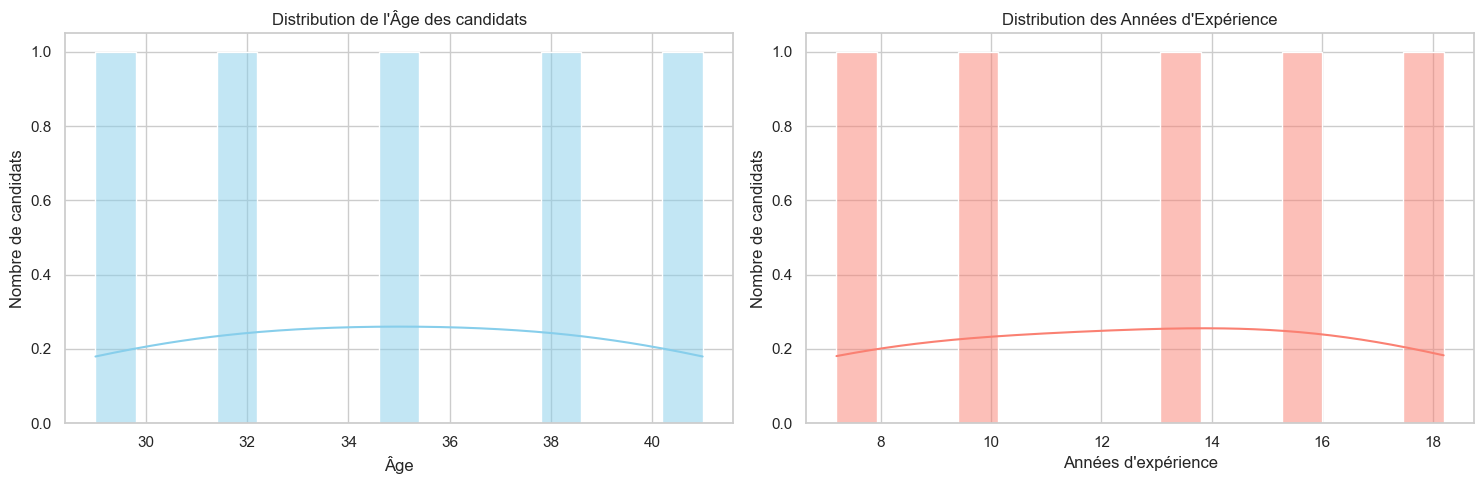

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution de l'âge
sns.histplot(df['age'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de l'Âge des candidats")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de candidats")

# Distribution de l'expérience totale
sns.histplot(df['total_experience_years'], bins=15, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribution des Années d'Expérience")
axes[1].set_xlabel("Années d'expérience")
axes[1].set_ylabel("Nombre de candidats")

plt.tight_layout()
plt.show()

## 4. Analyse Bivariée (Relations entre les variables)
Existe-t-il une corrélation forte entre l'âge et l'expérience ? Quels types de profils postulent pour quels rôles ?

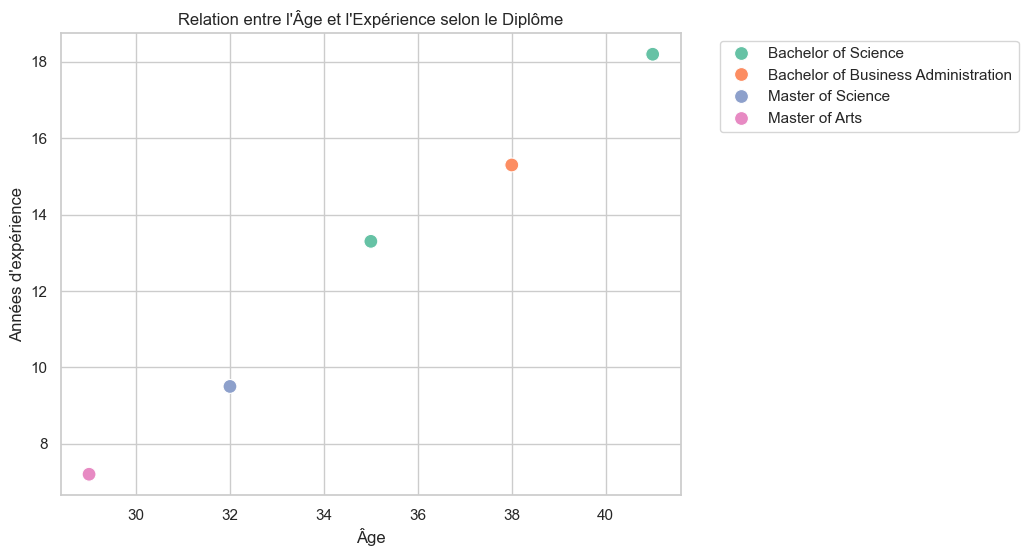

C:\Users\bourg\AppData\Local\Temp\ipykernel_11320\3502066684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')


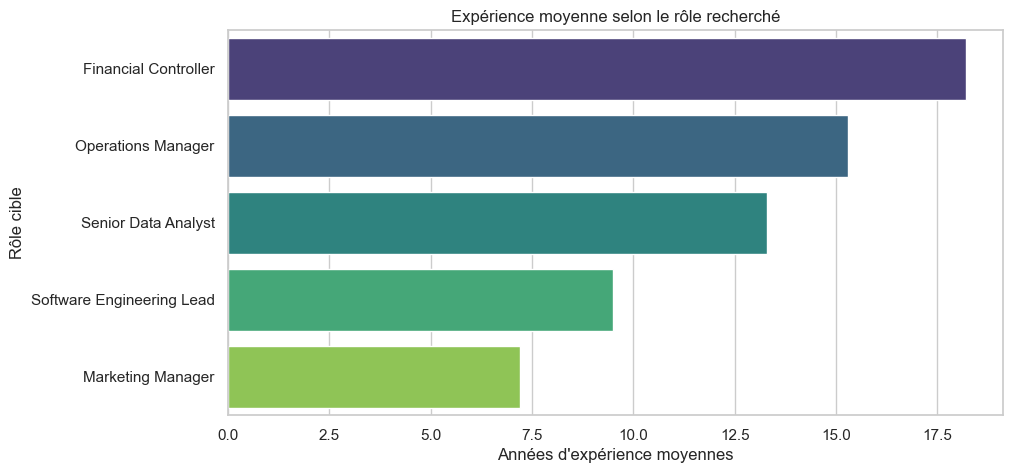

In [8]:
# Relation Âge vs Expérience
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='total_experience_years', hue='education_degree', s=100, palette='Set2')
plt.title("Relation entre l'Âge et l'Expérience selon le Diplôme")
plt.xlabel("Âge")
plt.ylabel("Années d'expérience")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Expérience moyenne par Rôle cible
plt.figure(figsize=(10, 5))
exp_by_role = df.groupby('target_role')['total_experience_years'].mean().sort_values(ascending=False)
sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')
plt.title("Expérience moyenne selon le rôle recherché")
plt.xlabel("Années d'expérience moyennes")
plt.ylabel("Rôle cible")
plt.show()

## 5. Analyse des Compétences Linguistiques
Puisque le jeu de données contient des scores pour différentes langues (FR, EN, DE, LU, ES, IT), analysons le niveau linguistique global des candidats.

C:\Users\bourg\AppData\Local\Temp\ipykernel_11320\3113012228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')


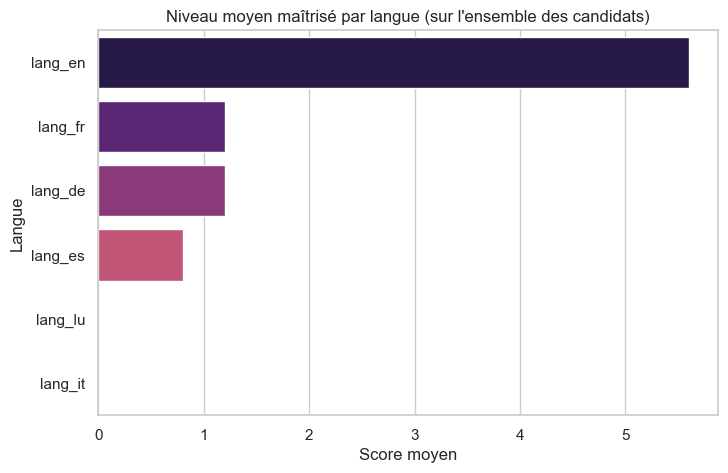

In [9]:
# Sélection des colonnes de langues
lang_cols = ['lang_fr', 'lang_en', 'lang_de', 'lang_lu', 'lang_es', 'lang_it']

# Calcul du niveau moyen pour chaque langue
mean_langs = df[lang_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')
plt.title("Niveau moyen maîtrisé par langue (sur l'ensemble des candidats)")
plt.xlabel("Score moyen")
plt.ylabel("Langue")
plt.show()

## 6. Analyse de la Matrice de Corrélation
Pour finir, nous pouvons générer une matrice de corrélation pour repérer mathématiquement les relations linéaires entre toutes nos variables numériques (ex: plus on est âgé, plus on habite loin ?).

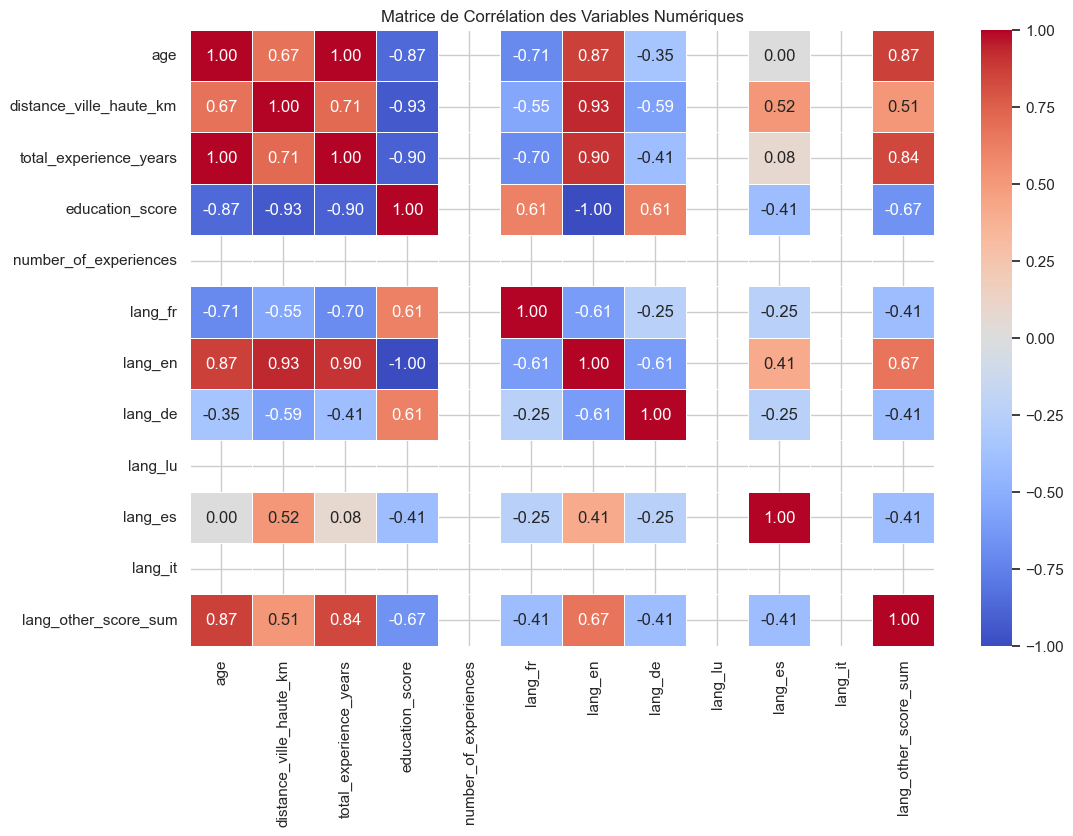

In [10]:
# Sélectionner uniquement les colonnes numériques
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
# Création d'une carte de chaleur (heatmap) des corrélations
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()